<a href="https://colab.research.google.com/github/Aswathi281099/Natural-Language-Processing-/blob/main/Project_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt

nltk.download('stopwords')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from textblob import TextBlob
from collections import Counter


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [3]:
df = pd.read_csv("StudentsPerformance.csv")

print("Dataset Shape:", df.shape)
print(df.head())


Dataset Shape: (1000, 8)
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  


In [4]:
df.columns


Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [5]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    value = str(text).lower()
    value = re.sub(r'[^a-zA-Z\s]', '', value)
    tokens = value.split()

    filtered_tokens = [
        lemmatizer.lemmatize(token)
        for token in tokens
        if token not in stop_words
    ]

    return " ".join(filtered_tokens)

df["cleaned_feedback"] = df["reading score"].map(clean_text)


In [7]:
def get_sentiment(text):
    score = TextBlob(text).sentiment.polarity

    if score > 0:
        label = "Positive"
    elif score < 0:
        label = "Negative"
    else:
        label = "Neutral"

    return label

df["sentiment"] = df["cleaned_feedback"].map(get_sentiment)

print("\nSentiment Counts")
print(df["sentiment"].value_counts())



Sentiment Counts
sentiment
Neutral    1000
Name: count, dtype: int64


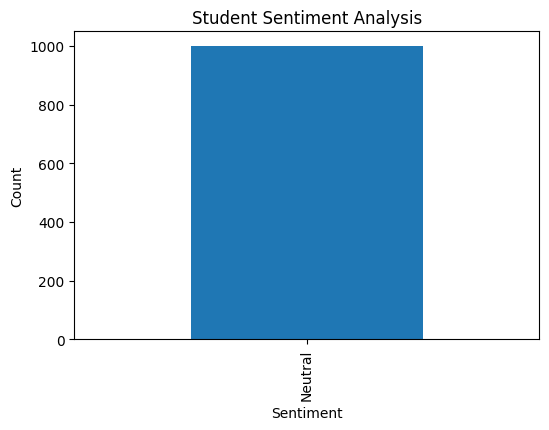

In [8]:
sentiment_counts = df["sentiment"].value_counts()

plt.figure(figsize=(6, 4))
sentiment_counts.plot(kind="bar")
plt.title("Student Sentiment Analysis")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()


In [9]:
negative_reviews = df.loc[df["sentiment"] == "Negative"]

all_words = " ".join(negative_reviews["cleaned_feedback"]).split()
word_freq = Counter(all_words)

print("\nCommon Student Concerns")

for word, count in word_freq.most_common(15):
    print(word, ":", count)



Common Student Concerns


In [10]:
positive = (df["sentiment"] == "Positive").sum()
negative = (df["sentiment"] == "Negative").sum()
neutral = (df["sentiment"] == "Neutral").sum()

print("\n" + "=" * 50)
print("STUDENT FEEDBACK REPORT")
print("=" * 50)

print("Positive Feedback :", positive)
print("Negative Feedback :", negative)
print("Neutral Feedback  :", neutral)

print("\nTop Concerns:")

for word, count in word_freq.most_common(10):
    print("-", word, "(", count, "mentions )")

print("\nImprovement Suggestions:")
print("1. Increase practical and lab sessions.")
print("2. Improve classroom facilities.")
print("3. Provide more study materials.")
print("4. Organize workshops and projects.")
print("5. Improve internet and library resources.")



STUDENT FEEDBACK REPORT
Positive Feedback : 0
Negative Feedback : 0
Neutral Feedback  : 1000

Top Concerns:

Improvement Suggestions:
1. Increase practical and lab sessions.
2. Improve classroom facilities.
3. Provide more study materials.
4. Organize workshops and projects.
5. Improve internet and library resources.
